In [21]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

import h5py
import flammkuchen as fl
import seaborn as sns
from matplotlib.cm import ScalarMappable
import scipy
from scipy import stats

In [23]:
from fig_2_helper import labels_cat, color, color_bouts, cmp_bouts, color_ipsi_cont

In [24]:
def reshape_feature_array(feature_vector_array):
    """
    Reshape the feature vector array into a specified shape and extract sub-arrays.

    Parameters:
    - feature_vector_array: numpy.ndarray, the array to be reshaped.

    Returns:
    - reshaped_array: numpy.ndarray, the reshaped array.
    - peaks_a_array, peaks_i_array, valleys_a_array, valleys_i_array: separate sub-arrays.
    """
    max_n = int(feature_vector_array.shape[1] / 4)

    # Reshape the array
    reshaped_array = feature_vector_array.reshape(feature_vector_array.shape[0], 4, max_n)

    # Extract sub-arrays
    peaks_a_array = reshaped_array[:, 0, :]
    peaks_i_array = reshaped_array[:, 1, :]
    valleys_a_array = reshaped_array[:, 2, :]
    valleys_i_array = reshaped_array[:, 3, :]

    print(f"Reshaped array shape: {reshaped_array.shape}")

    return reshaped_array, peaks_a_array, peaks_i_array, valleys_a_array, valleys_i_array
    
def resort_ipsi_contra_traces(left_fin, right_fin, ipsi_fin_values):
    """
    ipsi_fin = 0, left fin is ipsi, 
    ipsi_fin = 1, right fin is ipsi_fin,
    """
    ipsi_fin = np.zeros_like(left_fin)
    contra_fin = np.zeros_like(left_fin)

    for i, dir_value in enumerate(ipsi_fin_values):
        if dir_value == 0:  # Left 
            ipsi_fin[i] = left_fin[i]
            contra_fin[i] = right_fin[i]
        elif dir_value == 1:  # Right
            ipsi_fin[i] = right_fin[i]
            contra_fin[i] = left_fin[i]
    return ipsi_fin, contra_fin

def sort_ipsi_contra_arrays(array1, array2, ipsi_indicator):
    # Determine ipsilateral and contralateral
    """
    ipsi_fin = 0, left fin is ipsi, 
    ipsi_fin = 1, right fin is ipsi_fin,
    """
    ipsi_fin = np.full(array1.shape[0], np.nan)
    contra_fin = np.full(array2.shape[0], np.nan)

    for i, dir_value in enumerate(ipsi_indicator):
        if dir_value == 0:  # Left 
            ipsi_fin[i] = array1[i]
            contra_fin[i] = array2[i]
        elif dir_value == 1:  # Right
            ipsi_fin[i] = array2[i]
            contra_fin[i] = array1[i]
    return ipsi_fin, contra_fin

def get_ipsi_contra_col(df, col1, col2, ipsi_indicator_col):
    """
    Function to separate ipsilateral and contralateral fin durations.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    col1 (str): The name of the first duration column (e.g., 'l_fin_duration').
    col2 (str): The name of the second duration column (e.g., 'r_fin_duration').
    ipsi_indicator_col (str): The name of the column indicating which fin is ipsi (0 for col1, 1 for col2).

    Returns:
    np.ndarray: Array of ipsilateral fin durations.
    np.ndarray: Array of contralateral fin durations.
    """
    # Determine ipsilateral and contralateral durations
    ipsi_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col1], df[col2])
    contra_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col2], df[col1])
    
    return ipsi_fin_duration, contra_fin_duration
    

In [25]:
master_path = Path(r'\\portulab.synology.me\data\Kata\Processed_Data\tensor_data')
path_tensors = Path(master_path/ 'tensors'/'tensor_ipsi_contra_pos.h5')
path_features = Path(master_path/ 'features_bouts_new.csv')
laterality = fl.load(master_path/ 'features'/'bout_laterality.h5')
master_path, path_features

(WindowsPath('//portulab.synology.me/data/Kata/Processed_Data/tensor_data'),
 WindowsPath('//portulab.synology.me/data/Kata/Processed_Data/tensor_data/features_bouts_new.csv'))

In [26]:
save_figure_path = Path(r'\\portulab.synology.me\data\Kata\Figures_Paper\Figure_2\fig_2')

In [27]:
### tail, fin 1, fin 2, left eye, right eye

traces =  fl.load(path_tensors)
traces.shape

(11063, 3, 50)

In [28]:
tail = traces[:, 0, :]

ipsi_fin = traces[:, 1, :]
contra_fin = traces[:, 2, :]

### read in features

In [29]:
features = pd.read_csv(path_features)
features.head()

,Unnamed: 0,exp,fish_id,bout_angle,cluster,frame_start,frame_end,bout_id_orig,mb_proba,max_eye_rot,...,tail_freq,l_fin_freqs,r_fin_freqs,tail_max_freq,l_fin_max_freqs,r_fin_max_freqs,l_start,l_end,r_start,r_end
0,0,13052024_visstim_2D_round,240513_f0,3.000171,0,18375,18410,78,0.806645,-0.239648,...,0.121622,0.105263,0.109756,0.166667,0.166667,0.166667,0.0,27.0,0.0,28.0
1,1,13052024_visstim_2D_round,240513_f0,1.649302,0,19461,19484,80,1.000000,0.479035,...,0.058140,0.117647,0.119048,0.166667,0.166667,0.250000,0.0,15.0,7.0,26.0
2,2,13052024_visstim_2D_round,240513_f0,-0.861132,0,19661,19689,81,1.000000,-1.120168,...,0.097561,0.115385,0.104167,0.166667,0.166667,0.125000,4.0,20.0,0.0,27.0
3,3,13052024_visstim_2D_round,240513_f0,0.870591,0,20257,20292,84,1.000000,-2.662451,...,0.114286,0.117647,0.117647,0.166667,0.166667,0.125000,19.0,35.0,0.0,35.0
4,4,13052024_visstim_2D_round,240513_f0,2.231631,0,20824,20859,86,1.000000,-1.192489,...,0.108108,0.116667,0.103448,0.166667,0.125000,0.125000,0.0,23.0,6.0,28.0


In [30]:
clusters = features.cluster

In [31]:
ipsi_fin_values = features.ipsi_fin.values
ipsi_fin_values

array([1., 1., 1., ..., 0., 0., 1.])

## Square format

In [32]:
lw=0.5
cm = 1/2.54  # centimeters in inches
f_size = 6
dpi=600
alph= 0.5
width = 0.35  # Width of the bars

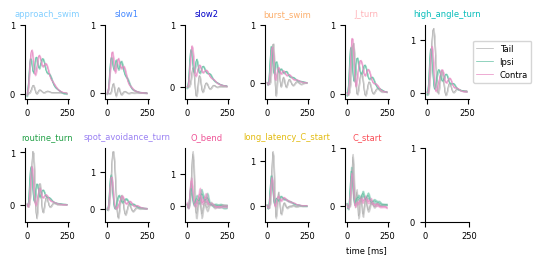

In [33]:

fig, axes = plt.subplots(2,6, figsize=(14*cm, 7*cm), facecolor='None')
axes= axes.ravel()

for i in range(11):
    axes[i].set_title(labels_cat[i], c=color[i], fontsize=f_size)

    axes[i].plot(np.mean(tail[clusters == i], axis=0) , c=color_ipsi_cont[2], alpha =1, lw=lw, label='Tail')
    axes[i].plot(np.mean(ipsi_fin[clusters == i], axis=0) , c=color_ipsi_cont[0], alpha =1,lw=lw,  label='Ipsi')
    axes[i].plot(np.mean(contra_fin[clusters == i], axis=0), c=color_ipsi_cont[1], alpha =1, lw=lw, label='Contra')

    select = tail[clusters == i]
    mean_line = np.mean(select, axis=0)
    stderr = np.std(select, axis=0) / np.sqrt(select.shape[0])
    # Plot confidence interval as a filled area
    axes[i].fill_between(np.arange(0,50,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color_ipsi_cont[2], 
                     alpha=alph)

    select = ipsi_fin[clusters == i]
    mean_line = np.mean(select, axis=0)
    stderr = np.std(select, axis=0) / np.sqrt(select.shape[0])
    # Plot confidence interval as a filled area
    axes[i].fill_between(np.arange(0,50,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color_ipsi_cont[0], 
                     alpha=alph)

    select = contra_fin[clusters == i]
    mean_line = np.mean(select, axis=0)
    stderr = np.std(select, axis=0) / np.sqrt(select.shape[0])
    # Plot confidence interval as a filled area
    axes[i].fill_between(np.arange(0,50,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color_ipsi_cont[1], 
                     alpha=alph)

for ax in axes:
    ax.set_yticks([0,1])
    ax.set_yticklabels([0,1], fontsize=f_size)
    ax.set_xticks([0,50])
    ax.set_xticklabels([0,250], fontsize=f_size)

axes[-2].set_xlabel('time [ms]', fontsize=f_size)
axes[5].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=f_size)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.tight_layout()
fig.savefig(save_figure_path / 'Traces_per_bout_cat_mean.pdf', dpi=dpi)
fig.savefig(save_figure_path / 'Traces_per_bout_cat_mean.png', dpi=dpi)

#### Get all tail angles

In [35]:
tail.shape

(11063, 50)

In [99]:
path_tensors = Path(master_path/ 'tensors'/ 'keypoint_angles_tensor.h5')
traces = fl.load(path_tensors)

In [100]:
bodyparts= [ 'body', 'left_eye', 'right_eye', 'left_fin', 'right_fin', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8', 'tail_9']
len(bodyparts)

15

In [101]:
traces_l_fin = traces[:, 3, :]
traces_r_fin = traces[:, 4, :]

traces_tail = traces[:,5:, :]
traces_l_fin.shape, traces_r_fin.shape, traces_tail.shape

((11063, 50), (11063, 50), (11063, 10, 50))

In [102]:
# tail_dir = features.tail_direction.values
# np.unique(tail_dir)

In [103]:
laterality = fl.load(r'\\portulab.synology.me\data\Kata\Processed_Data\tensor_data\sign.h5')
np.unique(laterality)

array([-1,  1])

In [109]:
import numpy as np

def flip_array_based_on_condition(array, tail_dir):
    # iterate over the array and flip the 2nd dimension if tail_dir is 0
    for i in range(array.shape[0]):
        if tail_dir[i] == 1:
            array[i] = np.flip(array[i], axis=0)
    return array


In [110]:
traces_tail_invert = flip_array_based_on_condition(traces_tail, laterality)

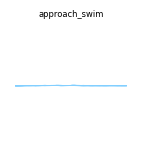

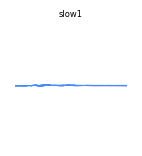

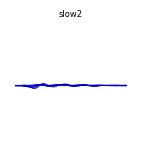

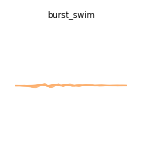

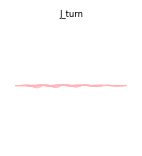

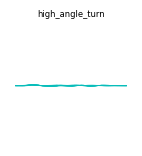

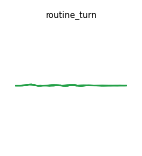

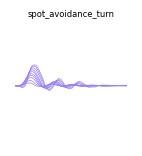

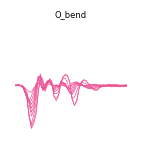

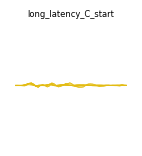

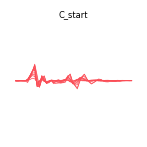

In [114]:

for i in range(11):
    plt.figure(figsize=(4*cm, 4*cm), facecolor='None')
    plt.title(labels_cat[i], c='k', fontsize=f_size)
    tra = traces_tail_invert[clusters == i][:]
    for seg in range(10):
        plt.plot(np.mean(tra[:, seg, :], axis=0), c=color[i], alpha =1, lw=lw)
    plt.axis('off')
    plt.ylim(-2, 2)

sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
fig.savefig(save_figure_path / 'Mean_trace_{}.pdf'.format(labels_cat[i]), dpi=dpi)
fig.savefig(save_figure_path / 'Mean_trace_{}.png'.format(labels_cat[i]), dpi=dpi)